# Task 1: Exploring and Visualizing the Iris Dataset

**Internship:** DevelopersHub Corporation — AI/ML Engineering  
**Task Objective:** Load, inspect, and visualize the Iris dataset to understand data distributions, feature relationships, and potential outliers.  
**Dataset:** Iris Dataset (loaded via Seaborn)  
**Tools Used:** Python, Pandas, Matplotlib, Seaborn

---

## 1. Import Libraries

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for all plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
import warnings

warnings.filterwarnings("ignore")  # Mutes all chatty warnings


## 2. Load the Dataset

In [2]:
# Load Iris dataset directly from Seaborn
df = sns.load_dataset("iris")

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset Shape: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


## 3. Initial Inspection

In [4]:
# First 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
# Data types and null value check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [6]:
# Summary statistics
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
# Class distribution
print("Species Count:")
print(df["species"].value_counts())

Species Count:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


**Insight:** The dataset has 150 rows and 5 columns with no missing values. It contains 3 species — setosa, versicolor, and virginica — each with exactly 50 samples. The dataset is perfectly balanced.

## 4. Data Visualization

### 4.1 Scatter Plot — Petal Length vs Petal Width

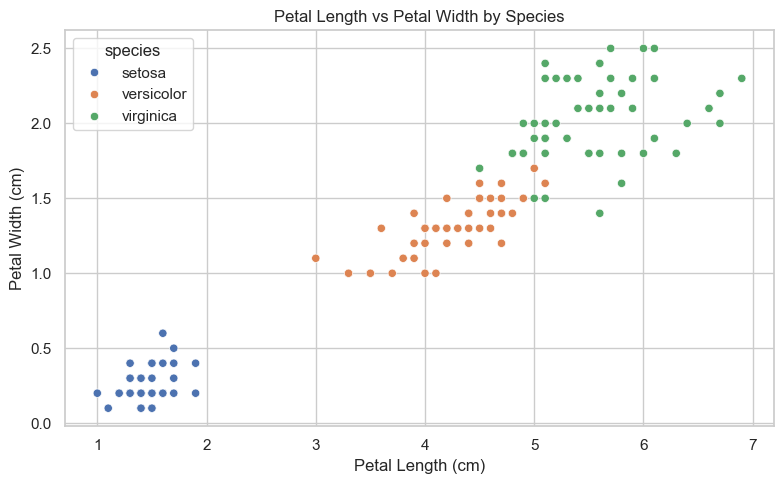

In [8]:
sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species",
    palette="deep"
)

plt.title("Petal Length vs Petal Width by Species")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.tight_layout()
plt.show()

**Insight:** Setosa is clearly separated from the other two species based on petal dimensions. Versicolor and Virginica overlap slightly, but petal features are strong indicators for classification.

### 4.2 Histograms — Feature Distributions

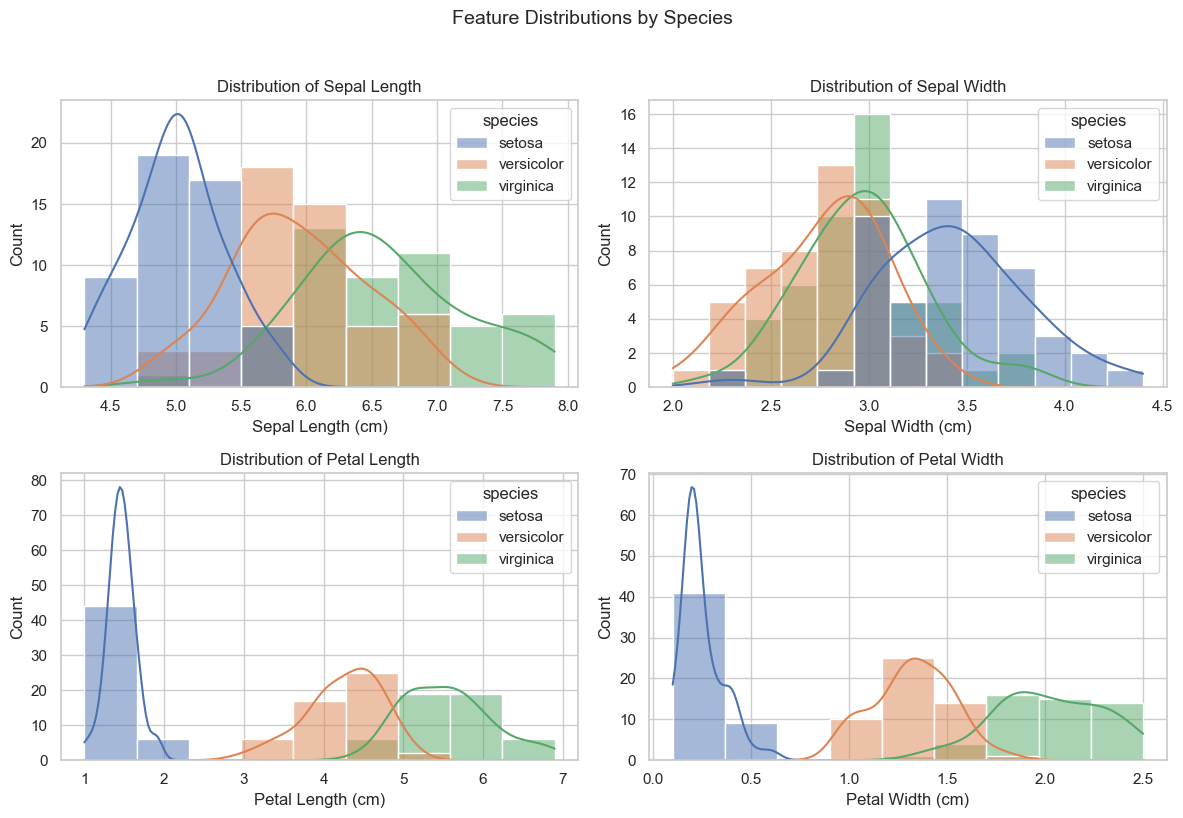

In [9]:
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        hue="species",
        kde=True,
        ax=axes[i],
        palette="deep"
    )
    axes[i].set_title(f"Distribution of {feature.replace('_', ' ').title()}")
    axes[i].set_xlabel(feature.replace('_', ' ').title() + " (cm)")

plt.suptitle("Feature Distributions by Species", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Insight:** Petal length and petal width show clear separation between species, making them more useful for classification. Sepal width distributions overlap significantly across species.

### 4.3 Box Plots — Outlier Detection

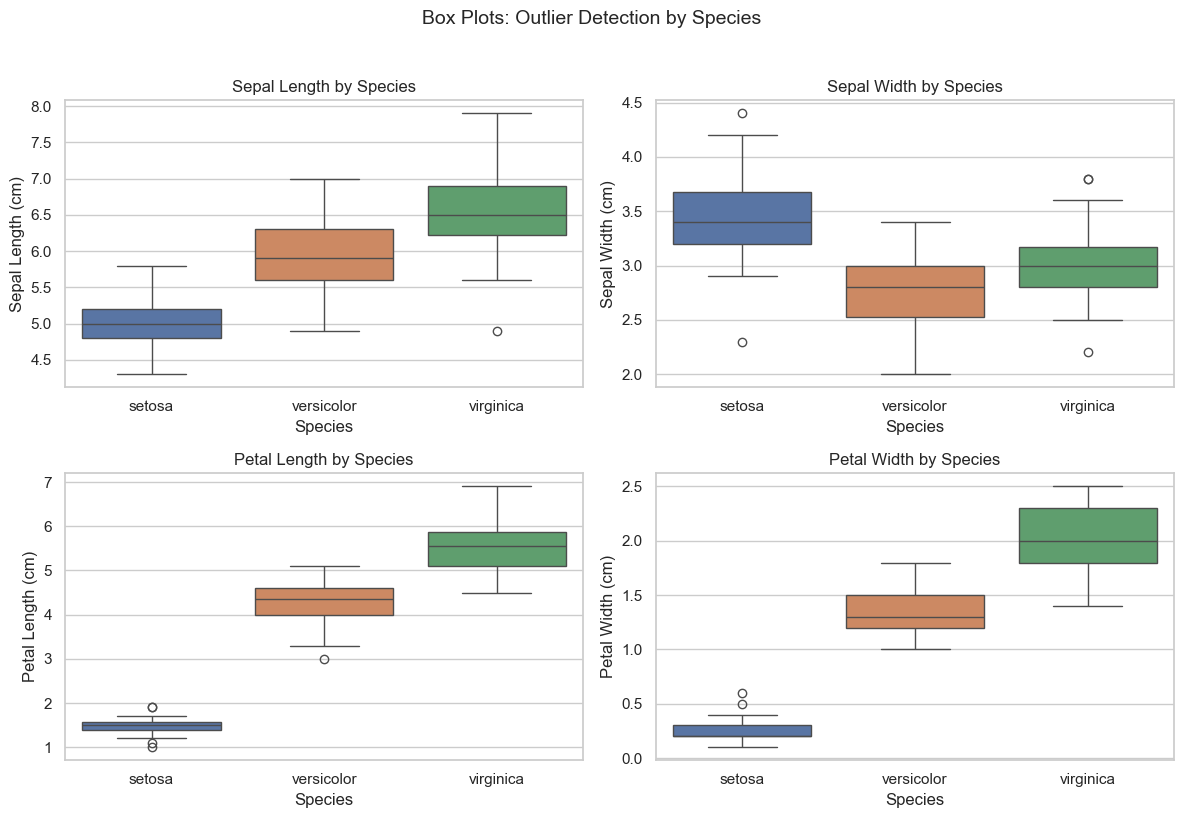

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x="species",
        y=feature,
        palette="deep",
        ax=axes[i]
    )
    axes[i].set_title(f"{feature.replace('_', ' ').title()} by Species")
    axes[i].set_xlabel("Species")
    axes[i].set_ylabel(feature.replace('_', ' ').title() + " (cm)")

plt.suptitle("Box Plots: Outlier Detection by Species", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Insight:** Sepal width of the Setosa species shows a few outliers. Overall, the dataset is clean with minimal extreme values, making it reliable for model training.

### 4.4 Correlation Heatmap

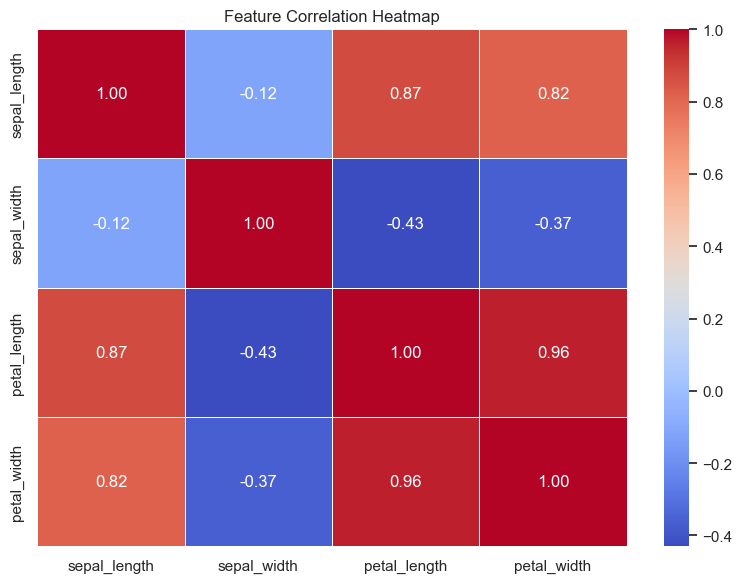

In [11]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.drop(columns="species").corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

**Insight:** Petal length and petal width are highly correlated (0.96), which confirms they carry similar information. This is useful to keep in mind when building classification models.

---

## 5. Key Findings & Conclusion

| Finding | Detail |
|---|---|
| Dataset Size | 150 rows, 5 columns, no missing values |
| Class Balance | Perfectly balanced — 50 samples per species |
| Best Features | Petal length and petal width (clearest separation) |
| Outliers | Minor outliers in sepal width for Setosa |
| Correlation | Petal length and petal width are highly correlated (0.96) |

**Conclusion:** The Iris dataset is clean, balanced, and well-structured. Petal-based features are the strongest differentiators between species and would be the most useful features for any classification model built on this data.

---
*DevelopersHub Corporation — AI/ML Engineering Internship | Task 1*